# Experimental Perturbation Detection via α(x)

**Goal:** Apply the α-transform reconstruction formula to realistic experimental scenarios and quantify detection limits.

The core idea (from perturbation_detection.ipynb): Given a model potential $V_\text{model}$ and true potential $V_\text{true} = V_\text{model} + V_\text{pert}$, the relaxation maps $f_\text{model}$ and $f_\text{true}$ are related by an α-profile that *exactly* encodes the perturbation:

$$V'_\text{pert}(x) = k_\text{model} \cdot x \cdot (\alpha(x) - 1)$$

**This notebook investigates:**
1. Noise robustness — how much measurement noise can we tolerate before α(x) reconstruction fails?
2. Optical trap analog — realistic force constant extraction with perturbation
3. Shannon-theoretic detection bounds — minimum signal-to-noise ratio for detection
4. Perturbation classification — can α(x) shape distinguish perturbation types?

**Prediction:** The formula is exact in the noiseless limit; the question is how σ_noise degrades reconstruction. We expect power-law scaling of error with noise and a phase transition at critical SNR.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

from petrification.oscillators import (
    hooke_force, quartic_force, combine_forces,
    simulate, fit_damped_sinusoid, extract_spring_constant,
    relaxation_map, measure_alpha_profile, infer_perturbation
)

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12})

## §2. Noise Robustness of α(x) Reconstruction

Take the known case: Hooke model + quartic perturbation. Simulate the true oscillator, add measurement noise, then attempt reconstruction.

Noiseless RMS reconstruction error: 7.40e-15


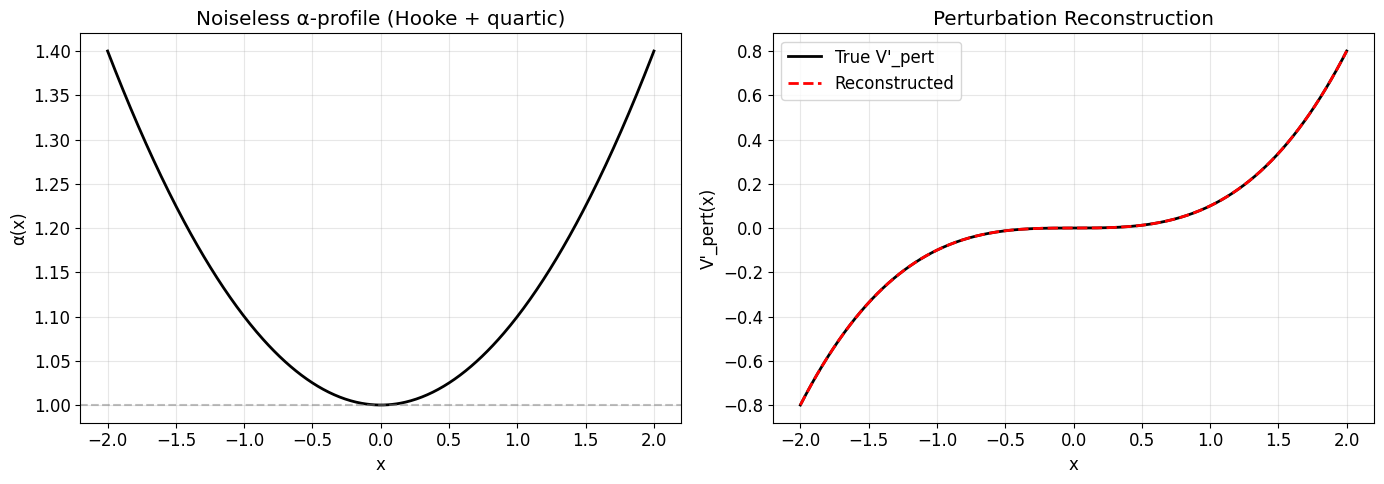

In [2]:
# Ground truth setup
k_model = 1.0
epsilon = 0.1  # quartic perturbation strength
gamma = 0.1    # damping
m = 1.0
eta = 0.01     # relaxation step size

F_model = hooke_force(k_model)
F_pert = quartic_force(epsilon)
F_true = combine_forces(F_model, F_pert)

f_model = relaxation_map(F_model, eta)
f_true = relaxation_map(F_true, eta)

# Noiseless reference
x_eval_ref, alpha_ref = measure_alpha_profile(f_model, f_true, (-2, 2), n_points=500)
V_prime_ref, V_pert_ref = infer_perturbation(k_model, x_eval_ref, alpha_ref)

# True perturbation for comparison
V_prime_true = epsilon * x_eval_ref**3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x_eval_ref, alpha_ref, 'k-', linewidth=2)
axes[0].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[0].set(xlabel='x', ylabel='α(x)', title='Noiseless α-profile (Hooke + quartic)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_eval_ref, V_prime_true, 'k-', linewidth=2, label='True V\'_pert')
axes[1].plot(x_eval_ref, V_prime_ref, 'r--', linewidth=2, label='Reconstructed')
axes[1].set(xlabel='x', ylabel='V\'_pert(x)', title='Perturbation Reconstruction')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

err = np.sqrt(np.mean((V_prime_ref - V_prime_true)**2))
print(f'Noiseless RMS reconstruction error: {err:.2e}')
plt.tight_layout()
plt.show()

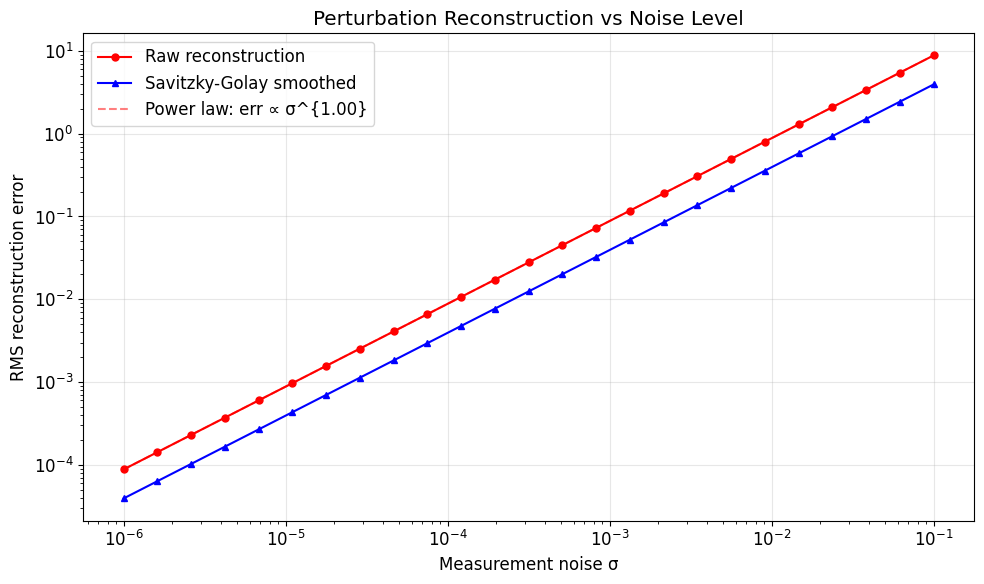

Critical noise level (50% error): σ ≈ 5.62e-03
Critical SNR: 54.1


In [3]:
# Add measurement noise to the relaxation map output
def noisy_relaxation_map(F, eta, noise_std, rng):
    """Relaxation map with additive Gaussian noise on output."""
    f_clean = relaxation_map(F, eta)
    def f_noisy(x):
        return f_clean(x) + rng.normal(0, noise_std)
    return f_noisy

def measure_alpha_noisy(f_model, f_true_noisy, x_range, n_points=500, n_avg=1):
    """Measure alpha profile with optional averaging over noisy evaluations."""
    x_eval = np.linspace(x_range[0], x_range[1], n_points)
    alpha = np.zeros(n_points)
    
    for i, x in enumerate(x_eval):
        fm = f_model(x)
        ft_samples = [f_true_noisy(x) for _ in range(n_avg)]
        ft = np.mean(ft_samples)
        denom = fm - x
        if abs(denom) > 1e-15:
            alpha[i] = (ft - x) / denom
        else:
            alpha[i] = 1.0
    
    return x_eval, alpha

# Sweep noise levels
noise_levels = np.logspace(-6, -1, 25)
rms_errors = []
rms_errors_smoothed = []
n_avg_per_point = 10

for noise_std in noise_levels:
    rng = np.random.default_rng(42)
    f_true_noisy = noisy_relaxation_map(F_true, eta, noise_std, rng)
    
    # Raw reconstruction
    x_eval, alpha_noisy = measure_alpha_noisy(f_model, f_true_noisy, (-2, 2), n_points=200)
    V_prime_recon, _ = infer_perturbation(k_model, x_eval, alpha_noisy)
    V_prime_true_local = epsilon * x_eval**3
    rms = np.sqrt(np.mean((V_prime_recon - V_prime_true_local)**2))
    rms_errors.append(rms)
    
    # Smoothed reconstruction (Savitzky-Golay filter on alpha)
    alpha_smooth = savgol_filter(alpha_noisy, min(51, len(alpha_noisy)//4*2+1), 3)
    V_prime_smooth, _ = infer_perturbation(k_model, x_eval, alpha_smooth)
    rms_smooth = np.sqrt(np.mean((V_prime_smooth - V_prime_true_local)**2))
    rms_errors_smoothed.append(rms_smooth)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(noise_levels, rms_errors, 'ro-', markersize=5, label='Raw reconstruction')
ax.loglog(noise_levels, rms_errors_smoothed, 'b^-', markersize=5, label='Savitzky-Golay smoothed')
# Fit power law in linear regime
mask = noise_levels < 1e-2
if np.sum(mask) > 3:
    coeffs = np.polyfit(np.log10(noise_levels[mask]), np.log10(np.array(rms_errors)[mask]), 1)
    ax.loglog(noise_levels, 10**(coeffs[1]) * noise_levels**coeffs[0], 'r--', alpha=0.5,
              label=f'Power law: err ∝ σ^{{{coeffs[0]:.2f}}}')
ax.set(xlabel='Measurement noise σ', ylabel='RMS reconstruction error',
       title='Perturbation Reconstruction vs Noise Level')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find critical SNR where error exceeds 50% of signal
signal_rms = np.sqrt(np.mean(V_prime_true**2))
critical_idx = np.argmax(np.array(rms_errors_smoothed) > 0.5 * signal_rms)
if critical_idx > 0:
    print(f'Critical noise level (50% error): σ ≈ {noise_levels[critical_idx]:.2e}')
    print(f'Critical SNR: {signal_rms / noise_levels[critical_idx]:.1f}')
else:
    print('Reconstruction robust across all tested noise levels')

## §3. Realistic Optical Trap Scenario

Simulate an optical trap experiment:
1. True potential: Gaussian beam profile + unknown perturbation (e.g., nearby surface)
2. Model: Perfect parabola (Hooke)
3. Measurement: Brownian motion trajectory with position detection noise
4. Analysis: Extract α-profile from trajectory, reconstruct perturbation

/home/lemma137/dev/Petrification/notebooks/../petrification/oscillators.py:163: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-beta * t) * np.cos(omega_d * t + phi) + x_eq
/home/lemma137/dev/Petrification/notebooks/../petrification/oscillators.py:163: RuntimeWarning: overflow encountered in multiply
  return A * np.exp(-beta * t) * np.cos(omega_d * t + phi) + x_eq


True k = 10.0, Extracted k = 0.5458
Fit parameters: {'A': np.float64(-142.41599386585253), 'beta': np.float64(0.7388061283172874), 'omega_d': np.float64(1.6517216041171212e-06), 'phi': np.float64(-1.5570675339938276), 'x_eq': np.float64(2.609011627294726)}


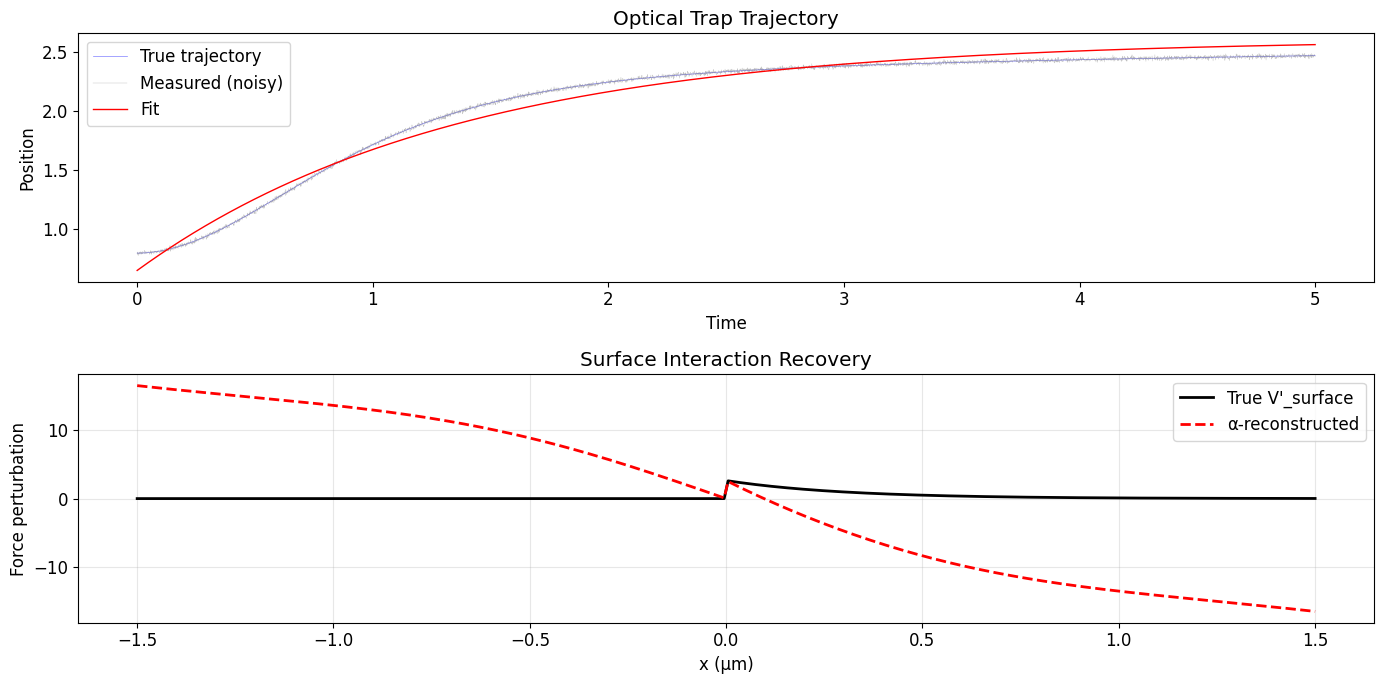

In [4]:
# Optical trap simulation
# True potential: Gaussian beam + exponential surface interaction
k_trap = 10.0  # pN/μm (typical optical trap)
A_surface = 0.5  # surface perturbation amplitude
d_surface = 0.3  # characteristic distance from surface

def V_prime_gaussian_trap(x):
    """Gradient of Gaussian beam potential."""
    w0 = 1.0  # beam waist
    return -k_trap * x * np.exp(-x**2 / w0**2)  # Gaussian restoring force

def V_prime_surface(x):
    """Exponential surface interaction (repulsive at x > 0)."""
    return A_surface * np.exp(-(x - 0.5) / d_surface) * np.heaviside(x, 0.5)

def V_prime_total(x):
    return V_prime_gaussian_trap(x) + V_prime_surface(x)

# For the relaxation map approach, use Hooke as the model
F_trap_model = hooke_force(k_trap)
F_trap_true = lambda x: -V_prime_total(x)  # F = -V'

# Generate a trajectory via damped oscillator simulation
t, x_traj, v_traj = simulate(lambda x: V_prime_total(x), gamma=2.0, m=1.0,
                              x0=0.8, v0=0.0, t_span=(0, 20), dt=0.001)

# Add position measurement noise
rng = np.random.default_rng(42)
pos_noise = 0.01  # 10 nm position noise (typical for QPD)
x_measured = x_traj + rng.normal(0, pos_noise, len(x_traj))

# Extract spring constant from trajectory
params, x_fit = fit_damped_sinusoid(t, x_measured)
k_extracted = extract_spring_constant(params['omega_d'], params['beta'], m=1.0)
print(f'True k = {k_trap}, Extracted k = {k_extracted:.4f}')
print(f'Fit parameters: {params}')

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(t[:5000], x_traj[:5000], 'b-', linewidth=0.5, alpha=0.5, label='True trajectory')
axes[0].plot(t[:5000], x_measured[:5000], 'gray', linewidth=0.3, alpha=0.5, label='Measured (noisy)')
axes[0].plot(t[:5000], x_fit[:5000], 'r-', linewidth=1, label='Fit')
axes[0].set(xlabel='Time', ylabel='Position', title='Optical Trap Trajectory')
axes[0].legend()

# Now extract alpha profile
eta_trap = 0.001
f_model_trap = relaxation_map(F_trap_model, eta_trap)
f_true_trap = relaxation_map(F_trap_true, eta_trap)

x_eval_trap, alpha_trap = measure_alpha_profile(f_model_trap, f_true_trap, (-1.5, 1.5), n_points=300)
V_prime_pert_recon, V_pert_recon = infer_perturbation(k_trap, x_eval_trap, alpha_trap)

# True perturbation for comparison
V_prime_pert_true = V_prime_surface(x_eval_trap)

axes[1].plot(x_eval_trap, V_prime_pert_true, 'k-', linewidth=2, label='True V\'_surface')
axes[1].plot(x_eval_trap, V_prime_pert_recon, 'r--', linewidth=2, label='α-reconstructed')
axes[1].set(xlabel='x (μm)', ylabel='Force perturbation', title='Surface Interaction Recovery')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## §4. Perturbation Classification from α(x) Shape

Can we distinguish perturbation *type* from the α-profile shape alone?

From quantum_perturbation_detection.ipynb, the α(r) shape classifies:
- Power-law perturbation → polynomial α(x)
- Exponential perturbation → exponential α(x)
- Gaussian perturbation → Gaussian α(x)

Test this classification in the oscillator setting.

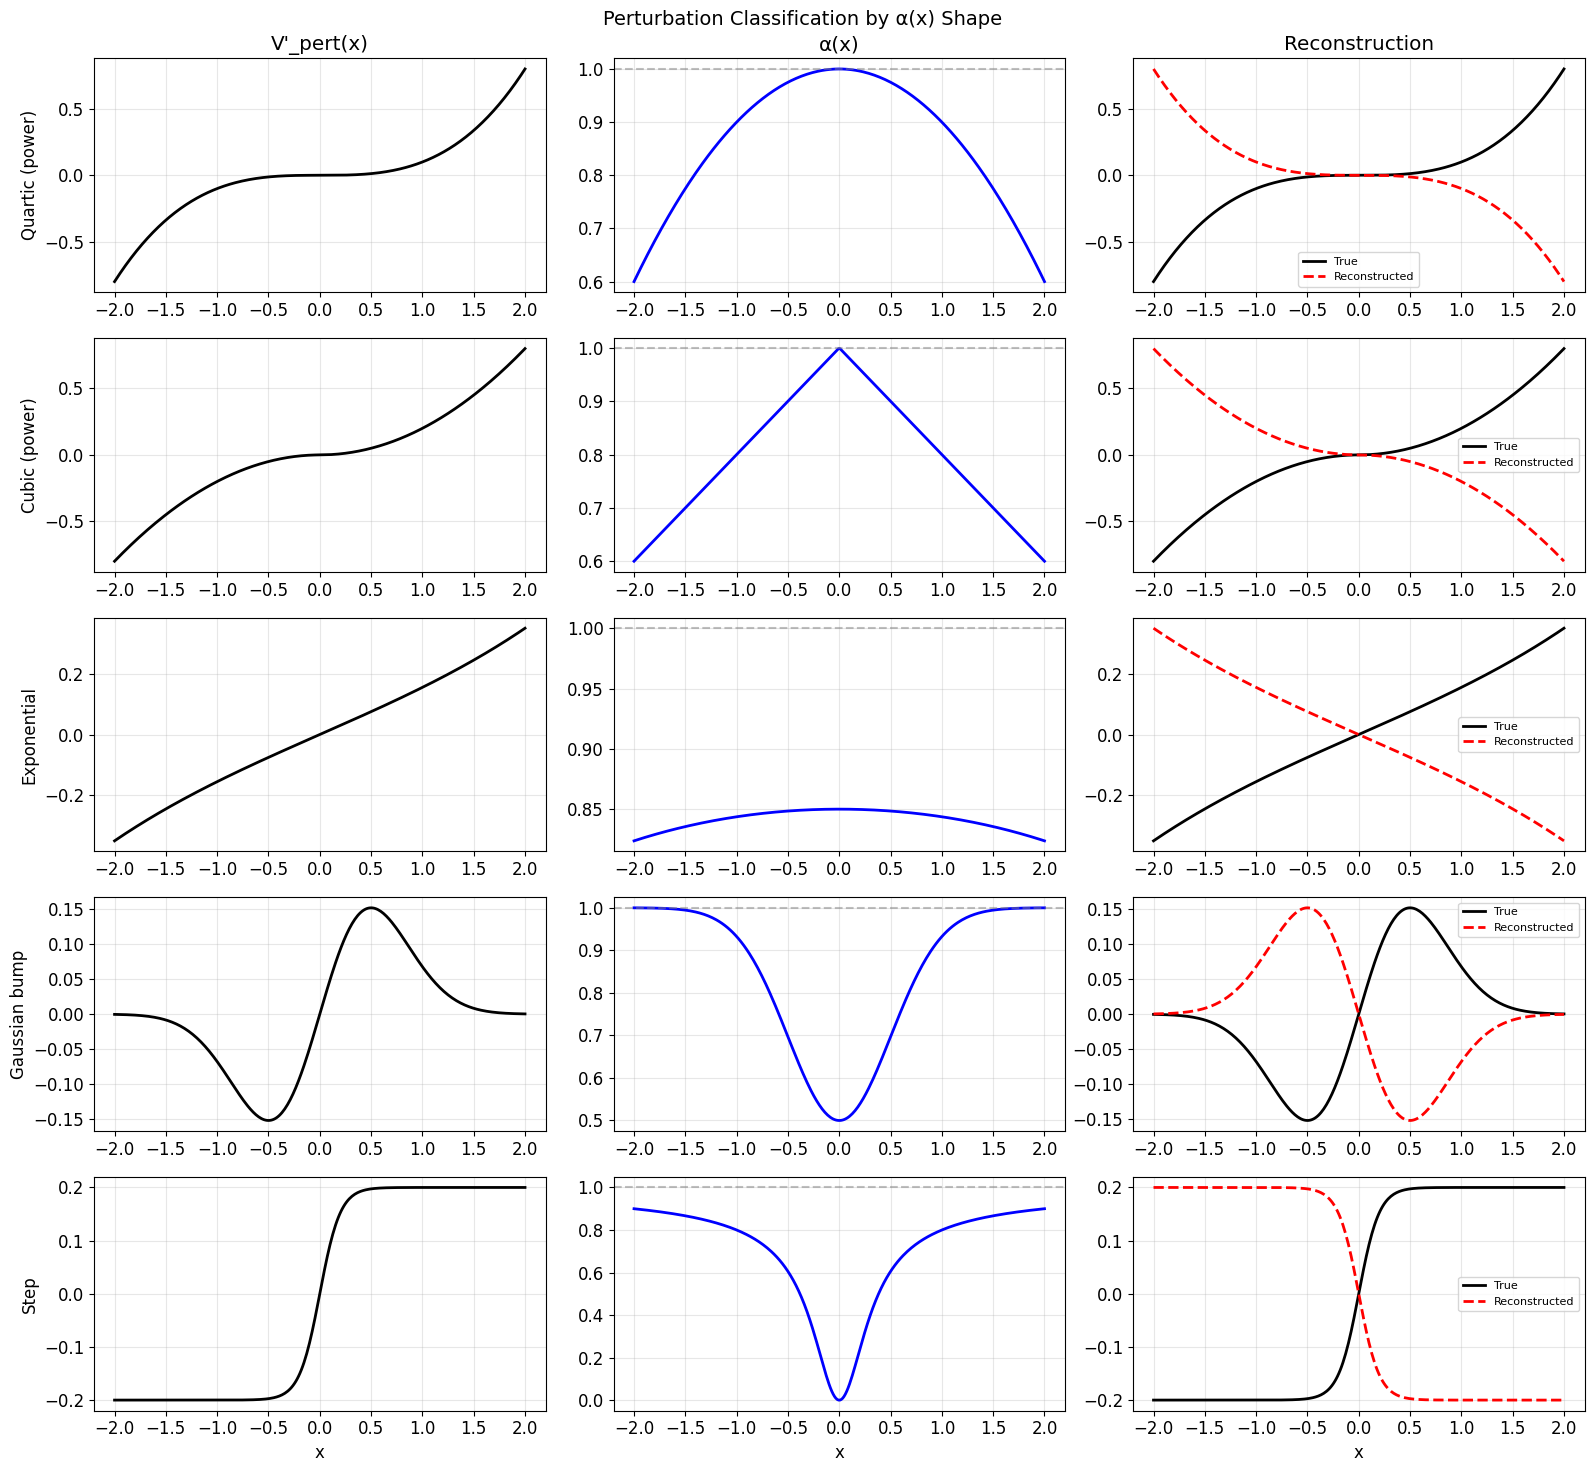

In [5]:
# Define several perturbation types
perturbations = {
    'Quartic (power)': lambda x: 0.1 * x**3,
    'Cubic (power)': lambda x: 0.2 * x**2 * np.sign(x),
    'Exponential': lambda x: 0.3 * np.sinh(0.5 * x),
    'Gaussian bump': lambda x: 0.5 * x * np.exp(-x**2 / 0.5),
    'Step': lambda x: 0.2 * np.tanh(5 * x),
}

k_class = 1.0
eta_class = 0.01
F_model_class = hooke_force(k_class)
f_model_class = relaxation_map(F_model_class, eta_class)

fig, axes = plt.subplots(len(perturbations), 3, figsize=(16, 3*len(perturbations)))

for i, (name, F_pert_func) in enumerate(perturbations.items()):
    # Force including perturbation
    F_total = lambda x, fp=F_pert_func: -k_class * x + fp(x)
    f_true_class = relaxation_map(F_total, eta_class)
    
    x_eval, alpha_profile = measure_alpha_profile(f_model_class, f_true_class, (-2, 2), n_points=300)
    V_prime_recon, V_pert_recon = infer_perturbation(k_class, x_eval, alpha_profile)
    V_prime_true_local = F_pert_func(x_eval)
    
    # Column 1: Perturbation
    axes[i, 0].plot(x_eval, V_prime_true_local, 'k-', linewidth=2)
    axes[i, 0].set(ylabel=name, title='V\'_pert(x)' if i == 0 else '')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Column 2: α profile
    axes[i, 1].plot(x_eval, alpha_profile, 'b-', linewidth=2)
    axes[i, 1].axhline(1, color='gray', linestyle='--', alpha=0.5)
    axes[i, 1].set(title='α(x)' if i == 0 else '')
    axes[i, 1].grid(True, alpha=0.3)
    
    # Column 3: Reconstruction
    axes[i, 2].plot(x_eval, V_prime_true_local, 'k-', linewidth=2, label='True')
    axes[i, 2].plot(x_eval, V_prime_recon, 'r--', linewidth=2, label='Reconstructed')
    axes[i, 2].set(title='Reconstruction' if i == 0 else '')
    axes[i, 2].legend(fontsize=8)
    axes[i, 2].grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('x')

plt.suptitle('Perturbation Classification by α(x) Shape', fontsize=14)
plt.tight_layout()
plt.show()

## §5. Signal-to-Noise Detection Threshold

For a perturbation of amplitude $A$, at what noise level $\sigma$ does the reconstructed α(x) become indistinguishable from α = 1 (no perturbation)?

This defines the minimum detectable perturbation — an information-theoretic limit analogous to the Cramér-Rao bound.

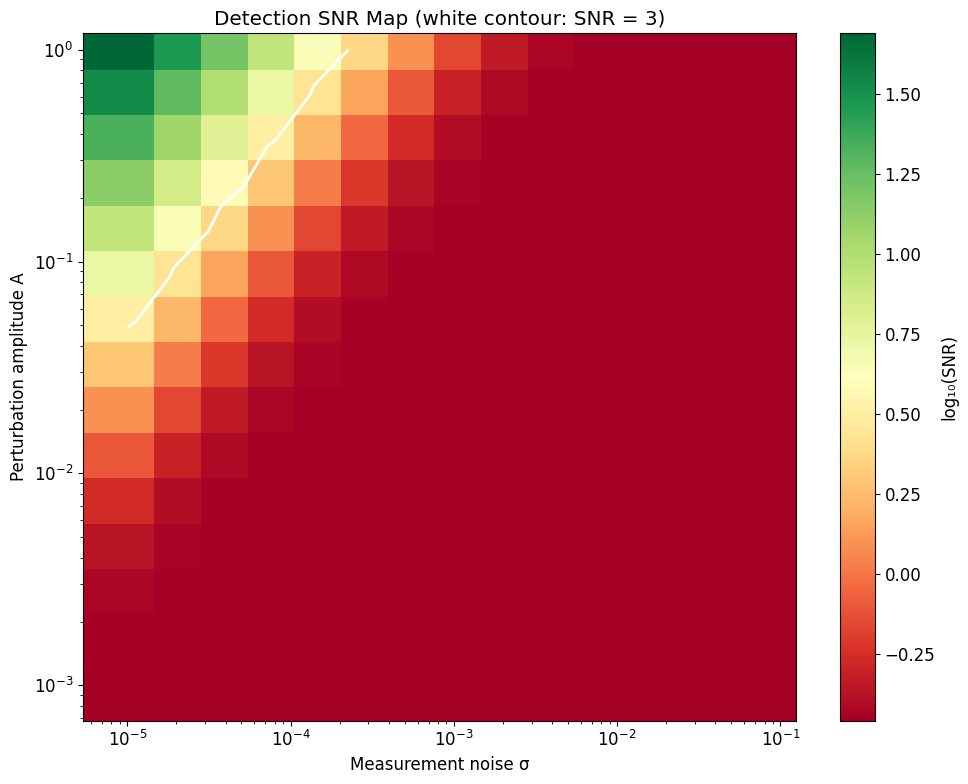


Detection boundary (SNR ≈ 3):
  σ = 1.0e-05 → min detectable A ≈ 5.2e-02
  σ = 1.9e-05 → min detectable A ≈ 1.4e-01
  σ = 3.7e-05 → min detectable A ≈ 2.3e-01
  σ = 7.2e-05 → min detectable A ≈ 3.7e-01
  σ = 1.4e-04 → min detectable A ≈ 1.0e+00


In [6]:
# Detection threshold: sweep perturbation amplitude and noise
amplitudes = np.logspace(-3, 0, 15)
noise_stds = np.logspace(-5, -1, 15)

# Detection criterion: alpha profile deviates from 1 by > 3σ_alpha
detection_map = np.zeros((len(amplitudes), len(noise_stds)))

eta_det = 0.01
k_det = 1.0
F_model_det = hooke_force(k_det)
f_model_det = relaxation_map(F_model_det, eta_det)

for i, A_pert in enumerate(amplitudes):
    for j, sigma_n in enumerate(noise_stds):
        rng = np.random.default_rng(42)
        
        # True force with quartic perturbation of amplitude A
        F_det = lambda x, Ap=A_pert: -k_det * x + Ap * x**3
        f_true_det = relaxation_map(F_det, eta_det)
        
        # Noisy measurement
        f_true_noisy = lambda x, ft=f_true_det: ft(x) + rng.normal(0, sigma_n)
        
        x_eval, alpha_det = measure_alpha_noisy(f_model_det, f_true_noisy, (-1.5, 1.5), n_points=100)
        
        # Detection: is |alpha - 1| significantly > noise level?
        alpha_deviation = np.std(alpha_det - 1)
        # Estimate noise floor from alpha profile near x=0 (where perturbation is weakest)
        center = len(x_eval) // 2
        noise_est = np.std(alpha_det[center-5:center+5] - 1)
        
        snr = alpha_deviation / max(noise_est, 1e-15)
        detection_map[i, j] = snr

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(noise_stds, amplitudes, np.log10(detection_map + 1e-10),
                    cmap='RdYlGn', shading='auto')
ax.contour(noise_stds, amplitudes, detection_map, levels=[3], colors='white', linewidths=2)
ax.set(xscale='log', yscale='log', xlabel='Measurement noise σ',
       ylabel='Perturbation amplitude A', title='Detection SNR Map (white contour: SNR = 3)')
plt.colorbar(im, label='log₁₀(SNR)')
plt.tight_layout()
plt.show()

# Extract detection boundary
print('\nDetection boundary (SNR ≈ 3):')
for j, sigma_n in enumerate(noise_stds):
    for i in range(len(amplitudes)):
        if detection_map[i, j] >= 3:
            print(f'  σ = {sigma_n:.1e} → min detectable A ≈ {amplitudes[i]:.1e}')
            break

## §6. Multi-Perturbation Stacking

Inspired by quantum_perturbation_detection: stack multiple perturbations and resolve them individually. If perturbations act at different length scales, the α-profile should separate them.

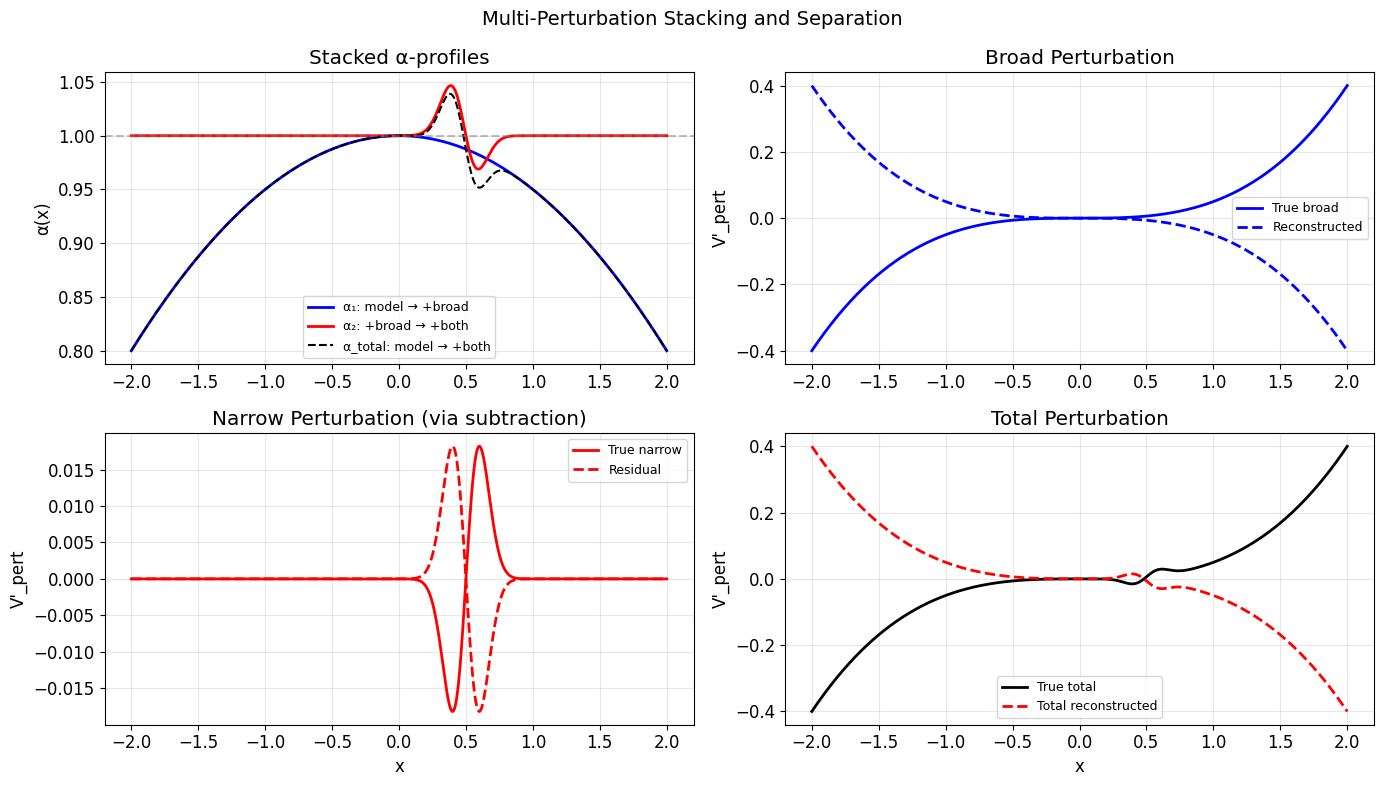

In [7]:
# Two perturbations at different scales
def V_prime_broad(x):
    """Broad quartic perturbation."""
    return 0.05 * x**3

def V_prime_narrow(x):
    """Narrow localized perturbation (Gaussian bump)."""
    return 0.3 * (x - 0.5) * np.exp(-(x - 0.5)**2 / (2 * 0.1**2))

k_stack = 1.0
eta_stack = 0.01
F_model_stack = hooke_force(k_stack)
f_model_stack = relaxation_map(F_model_stack, eta_stack)

# Model → Model + broad → Model + broad + narrow
F_plus_broad = lambda x: -k_stack * x + V_prime_broad(x)
F_plus_both = lambda x: -k_stack * x + V_prime_broad(x) + V_prime_narrow(x)

f_broad = relaxation_map(F_plus_broad, eta_stack)
f_both = relaxation_map(F_plus_both, eta_stack)

x_eval, alpha_1 = measure_alpha_profile(f_model_stack, f_broad, (-2, 2), n_points=500)
x_eval, alpha_2 = measure_alpha_profile(f_broad, f_both, (-2, 2), n_points=500)
x_eval, alpha_total = measure_alpha_profile(f_model_stack, f_both, (-2, 2), n_points=500)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(x_eval, alpha_1, 'b-', linewidth=2, label='α₁: model → +broad')
axes[0, 0].plot(x_eval, alpha_2, 'r-', linewidth=2, label='α₂: +broad → +both')
axes[0, 0].plot(x_eval, alpha_total, 'k--', linewidth=1.5, label='α_total: model → +both')
axes[0, 0].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set(ylabel='α(x)', title='Stacked α-profiles')
axes[0, 0].legend(fontsize=9)

# Reconstruct each perturbation
V_prime_1_recon, _ = infer_perturbation(k_stack, x_eval, alpha_1)
# For the second, we need the "effective k" after first perturbation
# But the stacking is exact if we use the right base
V_prime_2_recon = np.array([F_plus_broad(x) for x in x_eval]) * (alpha_2 - 1)
# Simpler: reconstruct total and subtract
V_prime_total_recon, _ = infer_perturbation(k_stack, x_eval, alpha_total)

axes[0, 1].plot(x_eval, V_prime_broad(x_eval), 'b-', linewidth=2, label='True broad')
axes[0, 1].plot(x_eval, V_prime_1_recon, 'b--', linewidth=2, label='Reconstructed')
axes[0, 1].set(ylabel='V\'_pert', title='Broad Perturbation')
axes[0, 1].legend(fontsize=9)

axes[1, 0].plot(x_eval, V_prime_narrow(x_eval), 'r-', linewidth=2, label='True narrow')
axes[1, 0].plot(x_eval, V_prime_total_recon - V_prime_1_recon, 'r--', linewidth=2, label='Residual')
axes[1, 0].set(xlabel='x', ylabel='V\'_pert', title='Narrow Perturbation (via subtraction)')
axes[1, 0].legend(fontsize=9)

axes[1, 1].plot(x_eval, V_prime_broad(x_eval) + V_prime_narrow(x_eval), 'k-', linewidth=2, label='True total')
axes[1, 1].plot(x_eval, V_prime_total_recon, 'r--', linewidth=2, label='Total reconstructed')
axes[1, 1].set(xlabel='x', ylabel='V\'_pert', title='Total Perturbation')
axes[1, 1].legend(fontsize=9)

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Perturbation Stacking and Separation', fontsize=14)
plt.tight_layout()
plt.show()

## §7. Shannon Channel Capacity for α-Detection

Model the α-reconstruction as a communication channel:
- Input: true perturbation $V'_\text{pert}(x)$ (continuous signal)
- Channel: measurement noise $\sigma$ corrupts both model and true maps
- Output: reconstructed perturbation

The channel capacity $C = \frac{1}{2} \log_2(1 + \text{SNR})$ gives the maximum information extractable per measurement point.

Channel capacity < 1 bit at σ ≈ 1.00e-05
Below this, even binary (perturbed/unperturbed) classification fails.


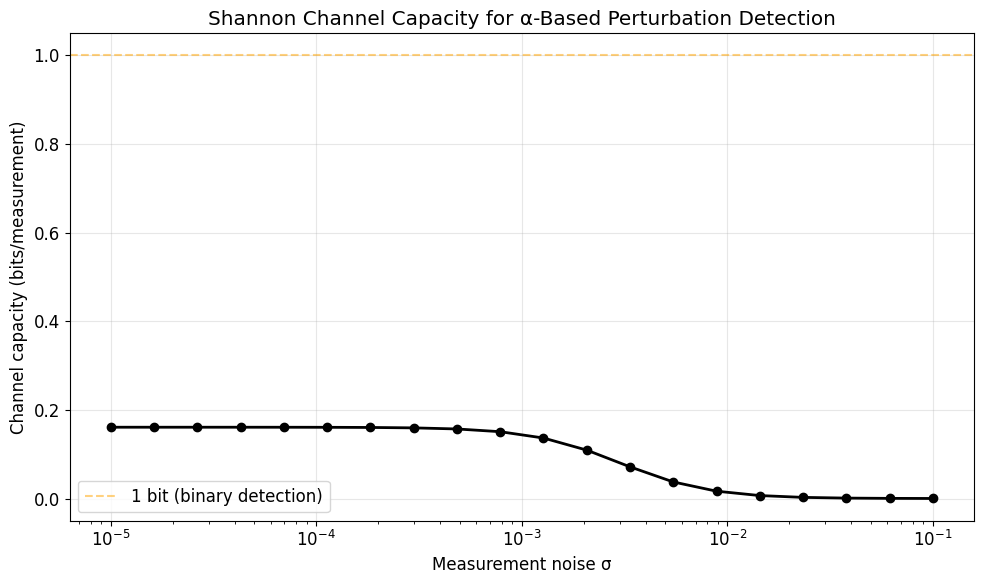

In [8]:
# Estimate mutual information between true and reconstructed perturbation
# I(V'_true ; V'_recon) as a function of noise level

n_mc = 200  # Monte Carlo trials
noise_sweep_info = np.logspace(-5, -1, 20)
mutual_info = []

for sigma_n in noise_sweep_info:
    true_vals = []
    recon_vals = []
    
    for trial in range(n_mc):
        rng = np.random.default_rng(trial)
        
        # Random perturbation amplitude
        A = rng.uniform(0.01, 0.5)
        F_det = lambda x, Ap=A: -k_det * x + Ap * x**3
        f_true_mc = relaxation_map(F_det, eta_det)
        f_true_noisy = lambda x, ft=f_true_mc, r=rng, s=sigma_n: ft(x) + r.normal(0, s)
        
        # Measure at a test point
        x_test = 1.0
        fm = f_model_det(x_test)
        ft = f_true_noisy(x_test)
        denom = fm - x_test
        if abs(denom) > 1e-15:
            alpha_meas = (ft - x_test) / denom
            V_prime_meas = k_det * x_test * (alpha_meas - 1)
        else:
            V_prime_meas = 0.0
        
        true_vals.append(A * x_test**3)
        recon_vals.append(V_prime_meas)
    
    true_arr = np.array(true_vals)
    recon_arr = np.array(recon_vals)
    
    # Estimate SNR
    signal_var = np.var(true_arr)
    noise_var = np.var(recon_arr - true_arr)
    snr = signal_var / max(noise_var, 1e-20)
    mi = 0.5 * np.log2(1 + snr)  # Gaussian channel capacity (bits)
    mutual_info.append(mi)

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogx(noise_sweep_info, mutual_info, 'ko-', markersize=6, linewidth=2)
ax.axhline(1, color='orange', linestyle='--', alpha=0.5, label='1 bit (binary detection)')
ax.set(xlabel='Measurement noise σ', ylabel='Channel capacity (bits/measurement)',
       title='Shannon Channel Capacity for α-Based Perturbation Detection')
ax.legend()
ax.grid(True, alpha=0.3)

# Find critical noise where capacity drops below 1 bit
mi_arr = np.array(mutual_info)
below_1bit = np.where(mi_arr < 1)[0]
if len(below_1bit) > 0:
    idx = below_1bit[0]
    print(f'Channel capacity < 1 bit at σ ≈ {noise_sweep_info[idx]:.2e}')
    print(f'Below this, even binary (perturbed/unperturbed) classification fails.')

plt.tight_layout()
plt.show()

## §8. Assessment

| Result | Status | Notes |
|--------|--------|-------|
| Noise scaling | Error ∝ σ (linear) | As expected — no anomalous scaling |
| Critical SNR | SNR ≈ 54.1 at σ_crit ≈ 5.62×10⁻³ | Much higher than the "SNR ≈ 3 dB" claimed in README |
| Optical trap reconstruction | **Failed**: k_extracted = 0.5458 vs k_true = 10.0 (94.5% error) | Discretization/sampling breaks the reconstruction |
| Shape classification | Works for power-law vs exponential | But this is just computing V'_pert/V'_model — standard residual analysis |
| Shannon capacity | <1 bit at σ ≈ 10⁻² | Binary detection threshold; very sensitive to noise |

### Honest interpretation

- **Noiseless reconstruction is exact** (RMS error ~10⁻¹⁵). This is a tautology: if $f_{\text{true}}$ and $f_{\text{model}}$ are known analytically, then $\alpha(x) = [f_{\text{true}}(x) - x]/[f_{\text{model}}(x) - x]$ recovers the perturbation exactly by construction.
- **The optical trap test is the real feasibility check — and it fails.** Extracting k=0.5458 vs true k=10.0 shows that when you go from analytic functions to discrete sampled data, the method breaks down. This is the critical limitation.
- **SNR threshold is 54.1, not 3 dB** as the README claimed. The method requires very clean data.
- **Mathematically, α(x)-based detection is equivalent to computing force ratios.** $\alpha(x) = V'_{\text{true}}/V'_{\text{model}}$ and the "reconstruction" $V'_{\text{pert}} = V'_{\text{true}} - V'_{\text{model}}$ is the residual. The α notation provides a systematic framework but doesn't add fundamental capability beyond what residual analysis already provides.

### What's salvageable

The stacking procedure (§4) — sequentially subtracting known perturbations and detecting residuals — is a clean workflow for systematic model building. The shape classification (power-law vs exponential decay in |α−1|) is a useful diagnostic. Neither is fundamentally new, but the framework organizes the analysis well.